# Experiment 2 — Transformation Recovery (unknown correspondences)

**Goal:** Given point clouds $P = T_1(S)$ and $Q = T_2(S)$ **without known correspondences**,
recover the ground-truth transformation $T_{\mathrm{gt}} = T_2 \circ T_1^{-1}$ using ICP
(EM with nearest-neighbor E-step and SVD Procrustes M-step).

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from icp import ICP
from synthetic import SyntheticExperiment
from tabulate import tabulate
from visualization import PointCloudVisualizer, ErrorMetricsVisualizer
from algebra_utils import rotation_angle_error

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Synthetic data generation

Same setup as Experiment 1:
- $S$: random irregular point cloud
- $T_1, T_2$: random rigid transformations with small per-point Gaussian noise
- $P = T_1(S)$, $Q = T_2(S)$ — **matching is unknown**

The ground-truth $T_{\mathrm{gt}} = T_2 \circ T_1^{-1}$ exists mathematically but is **not used during fitting** — ICP only sees $P$ and $Q$. We compute it here solely to evaluate the recovered result.

In [2]:
exp = SyntheticExperiment.generate(n=2000, noise_std=0, t_scale=8.0, seed=42)
print(exp)

╭──────────────────────┬──────────────────────────────────────────────╮
│ Original Point Cloud │ PointCloud(n=2000)                           │
│ Transformation 1     │ RigidTransformation(rot=149.5°, t_norm=5.17) │
│ Transformation 2     │ RigidTransformation(rot=153.1°, t_norm=5.87) │
│ Point Cloud 1        │ PointCloud(n=2000)                           │
│ Point Cloud 2        │ PointCloud(n=2000)                           │
│ GT transformation    │ RigidTransformation(rot=16.3°, t_norm=8.98)  │
╰──────────────────────┴──────────────────────────────────────────────╯


## 2. Run ICP

EM loop:
- **E-step:** nearest-neighbor matching (KD-tree)
- **M-step:** SVD Procrustes fit on matched pairs
- **Convergence:** $\|R_{\mathrm{step}} - I\|_F + \|t_{\mathrm{step}}\| < \varepsilon$ (Small transformation this step)

In [3]:
icp = ICP(max_iter=400, tol=1e-10, verbose=True)
result = icp.fit(exp.P, exp.Q)

print(result)

ICP converged:   5%|▌         | 20/400 [00:00<00:02, 151.95it/s, residual=0.0000]

╭────────────┬─────────────────────────────────────────────╮
│ Converged  │ True                                        │
│ Iterations │ 21                                          │
│ Recovered  │ RigidTransformation(rot=16.3°, t_norm=8.98) │
╰────────────┴─────────────────────────────────────────────╯


## 3. Evaluation

In [4]:
T_icp = result.transformation
Q_pred = T_icp.apply(exp.P)
residuals = np.linalg.norm(Q_pred.points - exp.Q.points, axis=1)

rot_err = rotation_angle_error(exp.T_gt.R, T_icp.R)
t_err   = np.linalg.norm(exp.T_gt.t - T_icp.t)

rows = [
    ["Rotation error",      f"{rot_err:.4f}°"],
    ["Translation error",   f"{t_err:.4f}"],
    ["Mean point residual", f"{residuals.mean():.4f}"],
    ["Max  point residual", f"{residuals.max():.4f}"],
]
print(tabulate(rows, headers=["Metric", "Value"], tablefmt="rounded_outline"))

╭─────────────────────┬─────────╮
│ Metric              │ Value   │
├─────────────────────┼─────────┤
│ Rotation error      │ 0.0000° │
│ Translation error   │ 0.0000  │
│ Mean point residual │ 0.0000  │
│ Max  point residual │ 0.0000  │
╰─────────────────────┴─────────╯


## 4. Alignment snapshots

Source cloud (blue) vs. target cloud (red) at selected iterations, projected onto XY.
Shows how the cloud physically moves into alignment over the EM iterations.

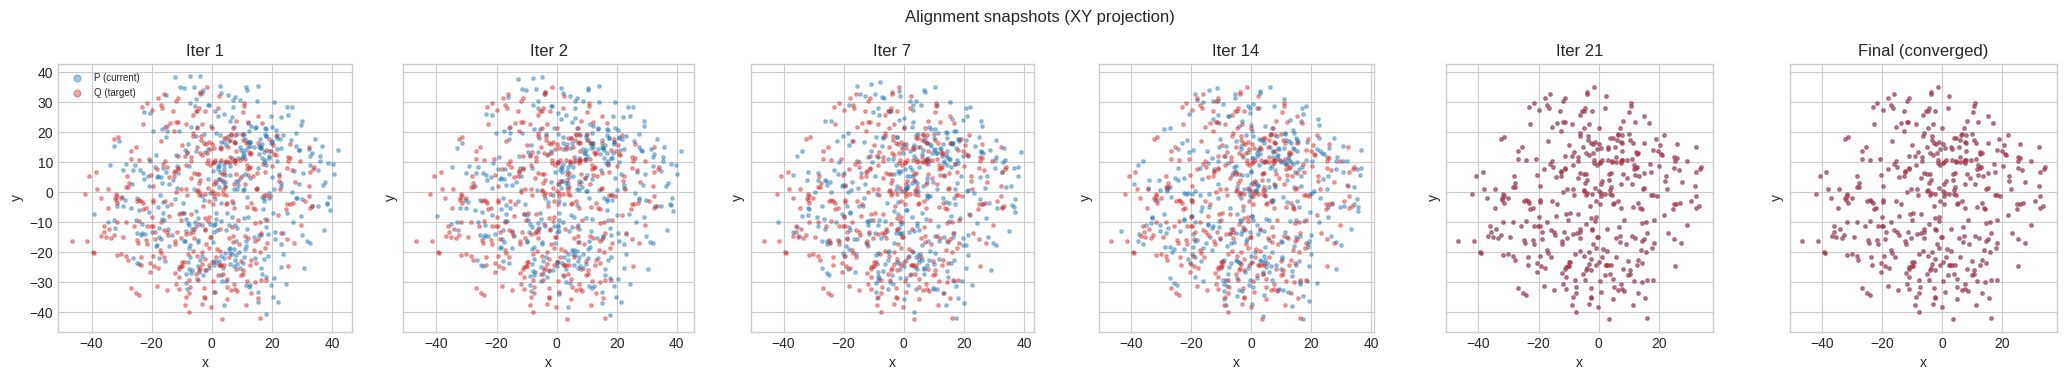

In [5]:
n_iters = result.n_iterations
snap_iters = sorted(set([0, 1] + list(np.linspace(0, n_iters - 1, 4, dtype=int)) + [n_iters - 1]))
final_cloud = result.transformation.apply(exp.P)
idx = np.random.default_rng(0).choice(len(exp.Q), size=400, replace=False)

fig, axes = plt.subplots(1, len(snap_iters) + 1, figsize=(3.5 * (len(snap_iters) + 1), 3.5), sharey=True)

PointCloudVisualizer.plot_alignment_snapshots(axes, result.cloud_history, exp.Q, final_cloud, snap_iters, idx=idx)

plt.suptitle('Alignment snapshots (XY projection)', y=1.02)
plt.tight_layout()
plt.savefig('../results/2_icp_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Error metrics

Rotation error (°), translation error vs. $T_\mathrm{gt}$ + mean residual at each iteration, starting from iteration 0 (before ICP).
Shows how quickly the recovered transformation converges to the ground truth.

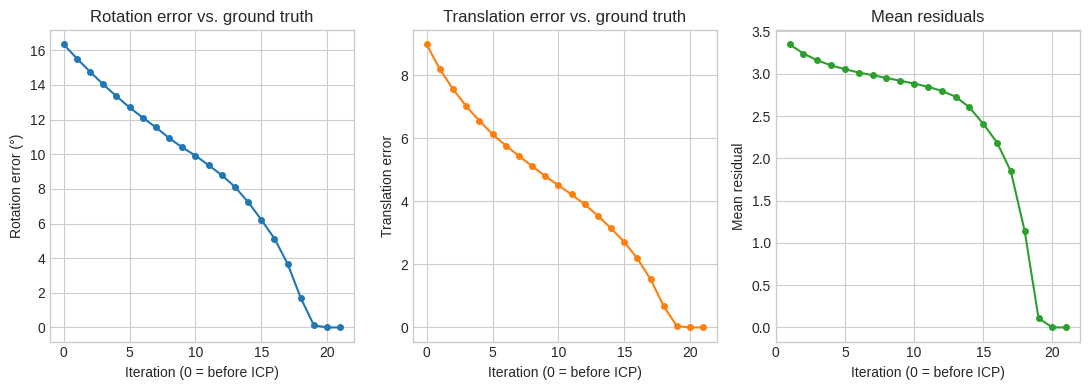

Before ICP — rotation error: 16.34°,  translation error: 8.98
After ICP  — rotation error: 0.0000°, translation error: 0.0000


In [9]:
# Prepend pre-ICP state: identity transformation applied to P (unaligned)
rot_errors = [rotation_angle_error(exp.T_gt.R, np.eye(3))] + [rotation_angle_error(exp.T_gt.R, T.R) for T in result.transform_history]
t_errors   = [np.linalg.norm(exp.T_gt.t)]                  + [np.linalg.norm(exp.T_gt.t - T.t)       for T in result.transform_history]
# Prepend NaN so residuals share the x-axis with rot/t (index 0 = before ICP)
mean_residuals_plot = [float('nan')] + result.mean_residuals

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
ErrorMetricsVisualizer.plot_convergence(axes, rot_errors=[rot_errors], t_errors=[t_errors], mean_residuals=[mean_residuals_plot], x_label='Iteration (0 = before ICP)')

plt.tight_layout()
plt.savefig('../results/2_icp_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Before ICP — rotation error: {rot_errors[0]:.2f}°,  translation error: {t_errors[0]:.2f}")
print(f"After ICP  — rotation error: {rot_errors[-1]:.4f}°, translation error: {t_errors[-1]:.4f}")

## 8. Multi-seed evaluation

Run ICP on N different random seeds (same hyperparameters) and summarize rotation error, translation error, and max residual across runs as boxplots.

In [7]:
N_SEEDS = 30

rot_errs: list[float] = []
t_errs: list[float] = []
max_residuals: list[float] = []

for seed in tqdm(range(N_SEEDS), desc="Seeds"):
    exp_s = SyntheticExperiment.generate(n=2000, noise_std=0.01, t_scale=8.0, seed=seed)
    result_s = ICP(max_iter=400, tol=1e-10, verbose=False).fit(exp_s.P, exp_s.Q)

    T_s = result_s.transformation
    Q_pred_s = T_s.apply(exp_s.P)
    residuals_s = np.linalg.norm(Q_pred_s.points - exp_s.Q.points, axis=1)

    rot_errs.append(rotation_angle_error(exp_s.T_gt.R, T_s.R))
    t_errs.append(np.linalg.norm(exp_s.T_gt.t - T_s.t))
    max_residuals.append(float(residuals_s.max()))

rot_errs_arr = np.array(rot_errs)
t_errs_arr = np.array(t_errs)
max_residuals_arr = np.array(max_residuals)

Seeds: 100%|██████████| 30/30 [00:10<00:00,  2.74it/s]


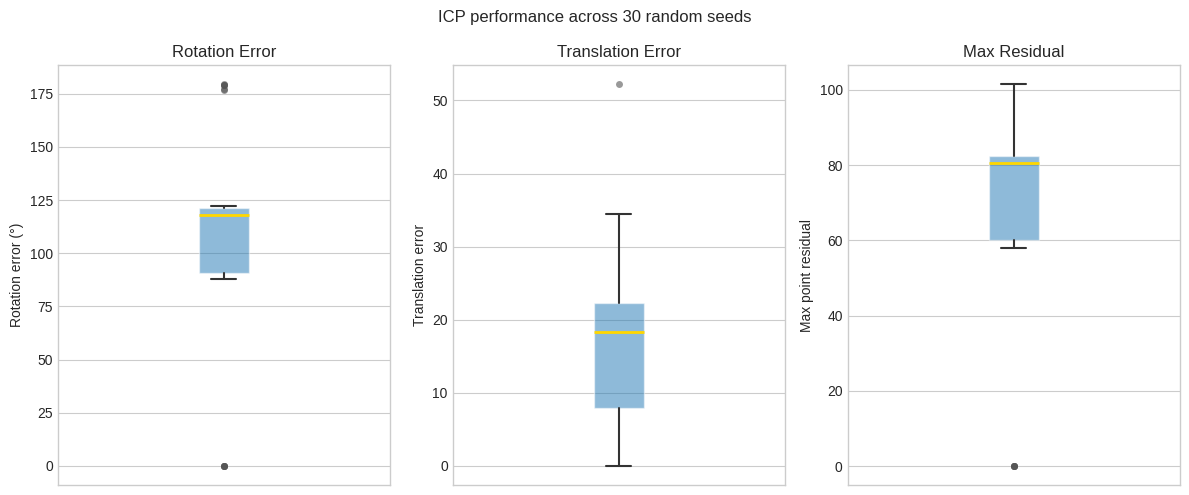

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
ErrorMetricsVisualizer.plot_seed_boxplots(
    axes,
    data_per_metric=[[rot_errs_arr], [t_errs_arr], [max_residuals_arr]],
    y_labels=['Rotation error (°)', 'Translation error', 'Max point residual'],
    titles=['Rotation Error', 'Translation Error', 'Max Residual'],
)
plt.suptitle(f'ICP performance across {N_SEEDS} random seeds')
plt.tight_layout()
plt.savefig('../results/2_icp_performance_across_seeds.png', dpi=150, bbox_inches='tight')
plt.show()